<a href="https://colab.research.google.com/github/diegomartinmendez/nyse_nasdaq_forecasting/blob/main/modelo_nuevo_2_corr_080_nan_40_train2021_ampliado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# modelo_nuevo_2_corr_080_nan_40_train2021_ampliado

In [ ]:
# ==================================================
# INSTALACIONES
# ==================================================

!pip install optuna
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.4 MB/s eta 0:00:00


In [ ]:
# ==================================================
# IMPORTS
# ==================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import pickle
from pathlib import Path

import torch
import torch.nn as nn
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from torch.utils.data import Dataset, DataLoader
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.family":      "sans-serif",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

In [ ]:
# ==================================================
# SEMILLAS
# ==================================================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
# ==================================================
# CARGA DE DATOS
# ==================================================

from google.colab import drive
drive.mount("/content/drive")

BASE_PATH = Path("/content/drive/MyDrive/Tesis/red_neuronal_final")

df_input_inicial = pd.read_parquet(BASE_PATH / "df_input_inicial.parquet")

if "iteracion" in df_input_inicial.columns:
    print("Columna 'iteracion' encontrada y eliminada.")
    df_input_inicial = df_input_inicial.drop(columns=["iteracion"])
else:
    print("Columna 'iteracion' no encontrada (se ignora).")

df_input_inicial["date_fundamentals"] = pd.to_datetime(
    df_input_inicial["date_fundamentals"]
)

print("Shape inicial:", df_input_inicial.shape)

Mounted at /content/drive
Columna 'iteracion' encontrada y eliminada.
Shape inicial: (688143, 323)


In [ ]:
# ==================================================
# LISTAS DE COLUMNAS
# ==================================================

target_col   = "target_return"
symbol_col   = "symbol"
date_col     = "date_fundamentals"

nan_threshold  = 0.40
corr_threshold = 0.80

ratios_origen_cols = [
    "grossProfitMargin", "ebitMargin", "ebitdaMargin",
    "operatingProfitMargin", "pretaxProfitMargin",
    "continuousOperationsProfitMargin", "netProfitMargin",
    "bottomLineProfitMargin", "receivablesTurnover",
    "payablesTurnover", "inventoryTurnover", "fixedAssetTurnover",
    "assetTurnover", "currentRatio", "quickRatio",
    "solvencyRatio", "cashRatio", "priceToEarningsRatio",
    "priceToEarningsGrowthRatio", "forwardPriceToEarningsGrowthRatio",
    "priceToBookRatio", "priceToSalesRatio",
    "priceToFreeCashFlowRatio", "priceToOperatingCashFlowRatio",
    "debtToAssetsRatio", "debtToEquityRatio", "debtToCapitalRatio",
    "longTermDebtToCapitalRatio", "financialLeverageRatio",
    "workingCapitalTurnoverRatio", "operatingCashFlowRatio",
    "operatingCashFlowSalesRatio", "freeCashFlowOperatingCashFlowRatio",
    "debtServiceCoverageRatio", "interestCoverageRatio",
    "shortTermOperatingCashFlowCoverageRatio",
    "operatingCashFlowCoverageRatio",
    "capitalExpenditureCoverageRatio",
    "dividendPaidAndCapexCoverageRatio",
    "dividendPayoutRatio", "dividendYield",
    "dividendYieldPercentage", "netIncomePerEBT",
    "ebtPerEbit", "priceToFairValue", "debtToMarketCap",
    "evToSales", "evToOperatingCashFlow", "evToFreeCashFlow",
    "evToEBITDA", "netDebtToEBITDA", "incomeQuality",
    "taxBurden", "interestBurden", "returnOnAssets",
    "operatingReturnOnAssets", "returnOnTangibleAssets",
    "returnOnEquity", "returnOnInvestedCapital",
    "returnOnCapitalEmployed", "earningsYield",
    "freeCashFlowYield", "capexToOperatingCashFlow",
    "capexToDepreciation", "capexToRevenue",
    "salesGeneralAndAdministrativeToRevenue",
    "researchAndDevelopmentToRevenue",
    "stockBasedCompensationToRevenue",
    "intangiblesToTotalAssets", "freeCashFlowToEquity",
    "freeCashFlowToFirm",
]

categorical_cols = [
    "exchange", "sector", "isEtf",
    "isActivelyTrading", "isAdr", "isFund",
]

In [ ]:
# ==================================================
# SPLIT TEMPORAL
# ==================================================

df_base = df_input_inicial.copy()

train_raw = df_base[df_base[date_col].dt.year <= 2021].copy()
valid_raw = df_base[
    (df_base[date_col].dt.year >= 2022)
    & (df_base[date_col].dt.year <= 2023)
].copy()
test_raw = df_base[df_base[date_col].dt.year >= 2024].copy()

print("Train raw:", train_raw.shape)
print("Valid raw:", valid_raw.shape)
print("Test raw: ", test_raw.shape)

Train raw: (551360, 323)
Valid raw: (77149, 323)
Test raw:  (59634, 323)


In [ ]:
# ==================================================
# TRANSFORMERS
# ==================================================

class BaseColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, ratios_origen_cols, categorical_cols,
                 target_col, symbol_col, date_col):
        self.ratios_origen_cols = ratios_origen_cols
        self.categorical_cols   = categorical_cols
        self.target_col         = target_col
        self.symbol_col         = symbol_col
        self.date_col           = date_col

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        cols = (
            [self.symbol_col, self.date_col]
            + self.ratios_origen_cols
            + self.categorical_cols
            + [self.target_col]
        )
        cols = [c for c in cols if c in X.columns]
        return X[cols].copy()


class ReplaceInf(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return X.replace([np.inf, -np.inf], np.nan)


class DropInvalidTarget(BaseEstimator, TransformerMixin):
    def __init__(self, target_col="target_return"):
        self.target_col = target_col

    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()
        X = X[X[self.target_col].notna()]
        X = X[X[self.target_col] != 0]
        X = X[X[self.target_col] > -1]
        return X


class ClipTargetOutliers(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.001, upper=0.999, target_col="target_return"):
        self.lower      = lower
        self.upper      = upper
        self.target_col = target_col

    def fit(self, X, y=None):
        self.lower_ = X[self.target_col].quantile(self.lower)
        self.upper_ = X[self.target_col].quantile(self.upper)
        print(f"ClipTargetOutliers — limites train: [{self.lower_:.4f}, {self.upper_:.4f}]")
        return self

    def transform(self, X):
        X = X.copy()
        if self.target_col not in X.columns:
            return X
        n_clipped = ((X[self.target_col] < self.lower_) | (X[self.target_col] > self.upper_)).sum()
        if n_clipped > 0:
            print(f"ClipTargetOutliers — filas winzorizadas: {n_clipped}")
        X[self.target_col] = X[self.target_col].clip(self.lower_, self.upper_)
        return X

    def fit_transform(self, X, y=None):
        self.fit(X, y)
        mask = X[self.target_col].between(self.lower_, self.upper_)
        n_dropped = (~mask).sum()
        if n_dropped > 0:
            print(f"ClipTargetOutliers — filas eliminadas en train: {n_dropped}")
        return X[mask].copy()


class DropHighNaNColumns(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.50, protected_cols=None):
        self.threshold      = threshold
        self.protected_cols = protected_cols or []

    def fit(self, X, y=None):
        self.cols_to_drop_ = X.columns[X.isna().mean() > self.threshold].tolist()
        self.cols_to_drop_ = [c for c in self.cols_to_drop_ if c not in self.protected_cols]
        print(f"DropHighNaNColumns — columnas eliminadas: {len(self.cols_to_drop_)}")
        return self

    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, errors="ignore")


class DropRowsWithAnyNaN(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self

    def transform(self, X):
        before = len(X)
        X = X.dropna().copy()
        print(f"DropRowsWithAnyNaN — filas eliminadas: {before - len(X)}")
        return X


class OneHotCategoricals(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_cols, exclude_cols=None):
        self.categorical_cols = categorical_cols
        self.exclude_cols     = exclude_cols or []

    def fit(self, X, y=None):
        self.cols_to_encode_ = [
            c for c in self.categorical_cols
            if c in X.columns and c not in self.exclude_cols
        ]
        self.encoder_ = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
        self.encoder_.fit(X[self.cols_to_encode_].astype(str))
        self.encoded_feature_names_ = self.encoder_.get_feature_names_out(self.cols_to_encode_)
        return self

    def transform(self, X):
        X = X.copy()
        if not self.cols_to_encode_:
            return X
        encoded    = self.encoder_.transform(X[self.cols_to_encode_].astype(str))
        encoded_df = pd.DataFrame(encoded, columns=self.encoded_feature_names_, index=X.index)
        X = X.drop(columns=self.cols_to_encode_)
        X = pd.concat([X, encoded_df], axis=1)
        return X


class CorrelationFilterDF(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95, exclude_cols=None):
        self.threshold    = threshold
        self.exclude_cols = exclude_cols or []

    def fit(self, X, y=None):
        numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c not in self.exclude_cols]
        corr_matrix  = X[numeric_cols].corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.cols_to_drop_ = [c for c in upper.columns if any(upper[c] > self.threshold)]
        print(f"CorrelationFilterDF — columnas eliminadas: {len(self.cols_to_drop_)}")
        return self

    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, errors="ignore")


class ScaleNumericFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_cols=None, ohe_prefixes=None):
        self.exclude_cols = exclude_cols or []
        self.ohe_prefixes = ohe_prefixes or []

    def _get_num_cols(self, X):
        return [
            c for c in X.columns
            if c not in self.exclude_cols
            and not any(c.startswith(p) for p in self.ohe_prefixes)
            and pd.api.types.is_numeric_dtype(X[c])
        ]

    def fit(self, X, y=None):
        self.num_cols_ = self._get_num_cols(X)
        self.scaler_   = StandardScaler()
        self.scaler_.fit(X[self.num_cols_])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.num_cols_] = self.scaler_.transform(X[self.num_cols_])
        return X

In [ ]:
# ==================================================
# PIPELINE
# ==================================================

ohe_prefixes = ["exchange_", "sector_", "isEtf_", "isActivelyTrading_", "isAdr_", "isFund_"]

pipeline = Pipeline(steps=[
    ("select_columns", BaseColumnSelector(
        ratios_origen_cols=ratios_origen_cols, categorical_cols=categorical_cols,
        target_col=target_col, symbol_col=symbol_col, date_col=date_col,
    )),
    ("replace_inf",          ReplaceInf()),
    ("drop_invalid_target",  DropInvalidTarget(target_col=target_col)),
    ("clip_target_outliers", ClipTargetOutliers(lower=0.001, upper=0.999, target_col=target_col)),
    ("drop_high_nan_cols",   DropHighNaNColumns(threshold=nan_threshold,
                                                protected_cols=[target_col, symbol_col, date_col])),
    ("drop_rows_with_nan",   DropRowsWithAnyNaN()),
    ("onehot",               OneHotCategoricals(categorical_cols=categorical_cols, exclude_cols=[symbol_col])),
    ("corr_filter",          CorrelationFilterDF(threshold=corr_threshold, exclude_cols=[target_col])),
    ("scale_numeric",        ScaleNumericFeatures(exclude_cols=[target_col, symbol_col, date_col],
                                                   ohe_prefixes=ohe_prefixes)),
])

In [ ]:
# ==================================================
# FIT / TRANSFORM
# ==================================================

train_df = pipeline.fit_transform(train_raw)
valid_df = pipeline.transform(valid_raw)
test_df  = pipeline.transform(test_raw)

print("\nShapes finales:")
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test: ", test_df.shape)

print("NaN train:", train_df.isna().sum().sum())
print("NaN valid:", valid_df.isna().sum().sum())
print("NaN test: ", test_df.isna().sum().sum())

ClipTargetOutliers — limites train: [-0.8349, 4.1020]
ClipTargetOutliers — filas eliminadas en train: 822
DropHighNaNColumns — columnas eliminadas: 0
DropRowsWithAnyNaN — filas eliminadas: 19064
CorrelationFilterDF — columnas eliminadas: 31
ClipTargetOutliers — filas winzorizadas: 393
DropRowsWithAnyNaN — filas eliminadas: 5665
ClipTargetOutliers — filas winzorizadas: 349
DropRowsWithAnyNaN — filas eliminadas: 1169

Shapes finales:
Train: (390293, 57)
Valid: (56226, 57)
Test:  (39591, 57)
NaN train: 0
NaN valid: 0
NaN test:  0


In [ ]:
# ==================================================
# FEATURES Y TARGET
# ==================================================

exclude_from_features = [target_col, symbol_col, date_col]

feature_cols = [
    c for c in train_df.columns
    if c not in exclude_from_features
    and pd.api.types.is_numeric_dtype(train_df[c])
]

print("\nTotal features:", len(feature_cols))

X_train = train_df[feature_cols].values.astype(np.float32)
X_valid = valid_df[feature_cols].values.astype(np.float32)
X_test  = test_df[feature_cols].values.astype(np.float32)

y_train = train_df[target_col].values.astype(np.float32)
y_valid = valid_df[target_col].values.astype(np.float32)
y_test  = test_df[target_col].values.astype(np.float32)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test: ", X_test.shape)


Total features: 54
X_train: (390293, 54)
X_valid: (56226, 54)
X_test:  (39591, 54)


In [ ]:
# ==================================================
# BASELINE
# ==================================================

y_train_mean  = y_train.mean()
baseline_pred = np.repeat(y_train_mean, len(y_test))

baseline_mse  = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_r2   = r2_score(y_test, baseline_pred)

print("\nBaseline (media de train):")
print(f"  MAE:  {baseline_mae:.6f}")
print(f"  RMSE: {baseline_rmse:.6f}")
print(f"  R2:   {baseline_r2:.6f}")


Baseline (media de train):
  MAE:  0.196052
  RMSE: 0.391632
  R2:   -0.000305


In [ ]:
# ==================================================
# DATASET PYTORCH
# ==================================================

class FinancialDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx): return self.X[idx], self.y[idx]

In [ ]:
# ==================================================
# MODELO
# ==================================================

class SimpleFinancialNN(nn.Module):
    def __init__(self, n_features, hidden_units, dropout, activation_name="relu"):
        super().__init__()
        activations = {
            "relu":       nn.ReLU(),
            "leaky_relu": nn.LeakyReLU(0.01),
            "elu":        nn.ELU(),
            "gelu":       nn.GELU(),
        }
        layers    = []
        input_dim = n_features
        for hidden_dim in hidden_units:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(activations[activation_name])
            layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)

In [ ]:
# ==================================================
# ENTRENAMIENTO
# Retorna además el historial de métricas por época
# para graficar las curvas de aprendizaje
# ==================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDispositivo:", device)


def train_one_model(params, epochs=30, patience=6, verbose=False, track_metrics=False):
    """
    track_metrics=True: registra MAE y RMSE en valid por época
    (solo para el entrenamiento final, no en los trials de Optuna)
    """
    train_dataset = FinancialDataset(X_train, y_train)
    valid_dataset = FinancialDataset(X_valid, y_valid)

    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=params["batch_size"], shuffle=False)

    model = SimpleFinancialNN(
        n_features      = X_train.shape[1],
        hidden_units    = params["hidden_units"],
        dropout         = params["dropout"],
        activation_name = params["activation"],
    ).to(device)

    criterion = nn.HuberLoss(delta=params["huber_delta"])
    optimizer  = torch.optim.AdamW(
        model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )

    history = {
        "train_loss": [], "valid_loss": [],
        "valid_mae":  [], "valid_rmse": [], "valid_r2": []
    }

    best_valid_loss  = np.inf
    best_state       = None
    patience_counter = 0

    for epoch in range(epochs):

        # --- Train ---
        model.train()
        train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            preds = model(x_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # --- Valid ---
        model.eval()
        valid_losses = []
        valid_preds  = []
        with torch.no_grad():
            for x_batch, y_batch in valid_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                preds   = model(x_batch)
                loss    = criterion(preds, y_batch)
                valid_losses.append(loss.item())
                if track_metrics:
                    valid_preds.extend(preds.cpu().numpy())

        train_loss = np.mean(train_losses)
        valid_loss = np.mean(valid_losses)

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)

        if track_metrics and valid_preds:
            vp = np.array(valid_preds)
            history["valid_mae"].append(mean_absolute_error(y_valid, vp))
            history["valid_rmse"].append(np.sqrt(mean_squared_error(y_valid, vp)))
            history["valid_r2"].append(r2_score(y_valid, vp))

        if verbose:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Valid Loss: {valid_loss:.6f}"
            )

        if valid_loss < best_valid_loss:
            best_valid_loss  = valid_loss
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping en epoca {epoch+1}.")
            break

    model.load_state_dict(best_state)
    return model, best_valid_loss, history


Dispositivo: cuda


In [ ]:
# ==================================================
# OPTUNA
# ==================================================

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    hidden_units = [
        trial.suggest_categorical(f"hidden_{i}", [64, 128, 256, 512])
        for i in range(n_layers)
    ]
    params = {
        "hidden_units": hidden_units,
        "dropout":      trial.suggest_float("dropout", 0.10, 0.50),
        "activation":   trial.suggest_categorical("activation", ["relu", "leaky_relu", "elu", "gelu"]),
        "lr":           trial.suggest_float("lr", 1e-5, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "batch_size":   trial.suggest_categorical("batch_size", [512, 1024, 2048]),
        "huber_delta":  trial.suggest_float("huber_delta", 0.5, 2.0),
    }
    _, valid_loss, _ = train_one_model(params=params, epochs=25, patience=3, verbose=False)
    return valid_loss


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("\nMejores hiperparametros:")
print(study.best_params)
print("Mejor valid loss:", study.best_value)


Mejores hiperparametros:
{'n_layers': 4, 'hidden_0': 512, 'hidden_1': 128, 'hidden_2': 256, 'hidden_3': 256, 'dropout': 0.24101212737175526, 'activation': 'elu', 'lr': 0.0008577174145410327, 'weight_decay': 2.8469908715287396e-06, 'batch_size': 2048, 'huber_delta': 0.5005216439848537}
Mejor valid loss: 0.038768691334553296


In [ ]:
# ==================================================
# ENTRENAMIENTO FINAL — con track_metrics=True
# ==================================================

best_params  = study.best_params
hidden_units = [best_params[f"hidden_{i}"] for i in range(best_params["n_layers"])]

final_params = {
    "hidden_units": hidden_units,
    "dropout":      best_params["dropout"],
    "activation":   best_params["activation"],
    "lr":           best_params["lr"],
    "weight_decay": best_params["weight_decay"],
    "batch_size":   best_params["batch_size"],
    "huber_delta":  best_params["huber_delta"],
}

final_model, best_valid_loss, history = train_one_model(
    params        = final_params,
    epochs        = 80,
    patience      = 6,
    verbose       = True,
    track_metrics = True,
)

Epoch   1/80 | Train Loss: 0.037928 | Valid Loss: 0.038937
Epoch   2/80 | Train Loss: 0.027161 | Valid Loss: 0.040526
Epoch   3/80 | Train Loss: 0.026546 | Valid Loss: 0.040518
Epoch   4/80 | Train Loss: 0.026399 | Valid Loss: 0.038931
Epoch   5/80 | Train Loss: 0.026387 | Valid Loss: 0.039078
Epoch   6/80 | Train Loss: 0.026373 | Valid Loss: 0.038904
Epoch   7/80 | Train Loss: 0.026372 | Valid Loss: 0.039039
Epoch   8/80 | Train Loss: 0.026343 | Valid Loss: 0.039190
Epoch   9/80 | Train Loss: 0.026347 | Valid Loss: 0.039079
Epoch  10/80 | Train Loss: 0.026321 | Valid Loss: 0.039174
Epoch  11/80 | Train Loss: 0.026340 | Valid Loss: 0.038587
Epoch  12/80 | Train Loss: 0.026335 | Valid Loss: 0.038984
Epoch  13/80 | Train Loss: 0.026327 | Valid Loss: 0.038534
Epoch  14/80 | Train Loss: 0.026370 | Valid Loss: 0.038942
Epoch  15/80 | Train Loss: 0.026314 | Valid Loss: 0.038799
Epoch  16/80 | Train Loss: 0.026321 | Valid Loss: 0.039187
Epoch  17/80 | Train Loss: 0.026309 | Valid Loss: 0.0408

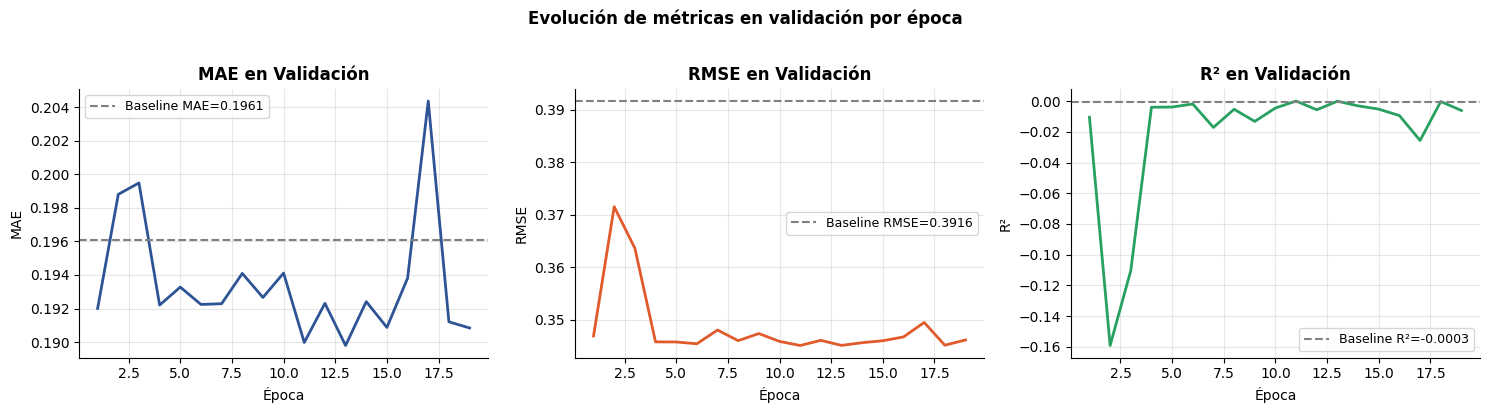

Grafico 2 guardado.


In [ ]:
# ==================================================
# GRAFICO 2: METRICAS EN VALID POR EPOCA (MAE, RMSE, R2)
# ==================================================

if history["valid_mae"]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ep = range(1, len(history["valid_mae"]) + 1)

    axes[0].plot(ep, history["valid_mae"],  color="#2E5496", linewidth=2)
    axes[0].axhline(baseline_mae, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline MAE={baseline_mae:.4f}")
    axes[0].set_title("MAE en Validación", fontweight="bold")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("MAE")
    axes[0].legend(fontsize=9)

    axes[1].plot(ep, history["valid_rmse"], color="#E05A2B", linewidth=2)
    axes[1].axhline(baseline_rmse, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline RMSE={baseline_rmse:.4f}")
    axes[1].set_title("RMSE en Validación", fontweight="bold")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("RMSE")
    axes[1].legend(fontsize=9)

    axes[2].plot(ep, history["valid_r2"],   color="#27A060", linewidth=2)
    axes[2].axhline(baseline_r2, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline R²={baseline_r2:.4f}")
    axes[2].set_title("R² en Validación", fontweight="bold")
    axes[2].set_xlabel("Época")
    axes[2].set_ylabel("R²")
    axes[2].legend(fontsize=9)

    plt.suptitle("Evolución de métricas en validación por época", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(BASE_PATH / "grafico_metricas_validacion.png", dpi=150)
    plt.show()
    print("Grafico 2 guardado.")

In [ ]:
# ==================================================
# EVALUACION EN TEST
# ==================================================

test_dataset = FinancialDataset(X_test, y_test)
test_loader  = DataLoader(test_dataset, batch_size=final_params["batch_size"], shuffle=False)

final_model.eval()
preds_test = []

with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)
        preds   = final_model(x_batch)
        preds_test.extend(preds.cpu().numpy())

preds_test = np.array(preds_test)

clip_lower    = train_df[target_col].quantile(0.001)
clip_upper    = train_df[target_col].quantile(0.999)
preds_clipped = np.clip(preds_test, clip_lower, clip_upper)

mse_raw  = mean_squared_error(y_test, preds_test)
mse_clip = mean_squared_error(y_test, preds_clipped)
mae_clip  = mean_absolute_error(y_test, preds_clipped)
rmse_clip = np.sqrt(mse_clip)
r2_clip   = r2_score(y_test, preds_clipped)

print("\n=== Metricas en Test ===")
print(f"{'':20} {'Baseline':>12} {'Modelo raw':>12} {'Modelo clip':>12}")
print(f"{'MSE':20} {baseline_mse:12.6f} {mse_raw:12.6f} {mse_clip:12.6f}")
print(f"{'RMSE':20} {baseline_rmse:12.6f} {np.sqrt(mse_raw):12.6f} {rmse_clip:12.6f}")
print(f"{'MAE':20} {baseline_mae:12.6f} {mean_absolute_error(y_test, preds_test):12.6f} {mae_clip:12.6f}")
print(f"{'R2':20} {baseline_r2:12.6f} {r2_score(y_test, preds_test):12.6f} {r2_clip:12.6f}")


=== Metricas en Test ===
                         Baseline   Modelo raw  Modelo clip
MSE                      0.153376    14.005939     0.154878
RMSE                     0.391632     3.742451     0.393546
MAE                      0.196052     0.211946     0.193322
R2                      -0.000305   -90.345535    -0.010103


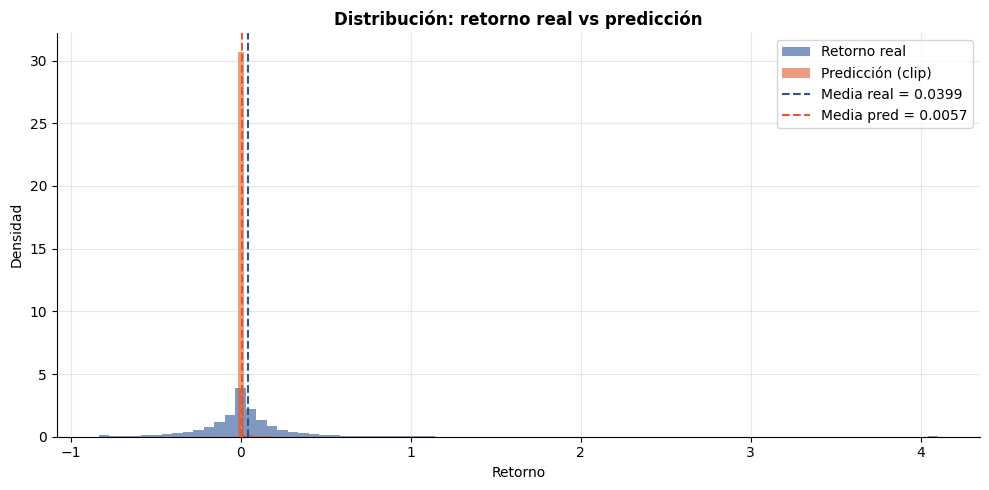

Grafico 3 guardado.


In [ ]:
# ==================================================
# GRAFICO 3: DISTRIBUCION predicciones vs reales
# ==================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_test, bins=80, alpha=0.6, color="#2E5496", label="Retorno real", density=True)
ax.hist(preds_clipped, bins=80, alpha=0.6, color="#E05A2B", label="Predicción (clip)", density=True)
ax.axvline(y_test.mean(),        color="#2E5496", linestyle="--", linewidth=1.5,
           label=f"Media real = {y_test.mean():.4f}")
ax.axvline(preds_clipped.mean(), color="#E05A2B", linestyle="--", linewidth=1.5,
           label=f"Media pred = {preds_clipped.mean():.4f}")
ax.set_xlabel("Retorno")
ax.set_ylabel("Densidad")
ax.set_title("Distribución: retorno real vs predicción", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(BASE_PATH / "grafico_distribucion.png", dpi=150)
plt.show()
print("Grafico 3 guardado.")

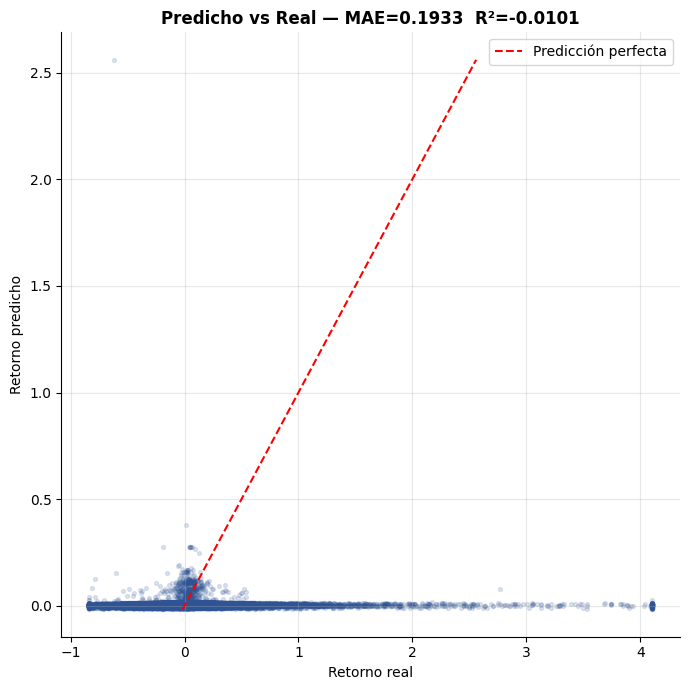

Grafico 4 guardado.


In [ ]:
# ==================================================
# GRAFICO 4: SCATTER predicho vs real
# ==================================================

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, preds_clipped, alpha=0.15, s=8, color="#2E5496", rasterized=True)
lims = [max(y_test.min(), preds_clipped.min()), min(y_test.max(), preds_clipped.max())]
ax.plot(lims, lims, color="red", linewidth=1.5, linestyle="--", label="Predicción perfecta")
ax.set_xlabel("Retorno real")
ax.set_ylabel("Retorno predicho")
ax.set_title(f"Predicho vs Real — MAE={mae_clip:.4f}  R²={r2_clip:.4f}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(BASE_PATH / "grafico_scatter.png", dpi=150)
plt.show()
print("Grafico 4 guardado.")

In [ ]:
# ==================================================
# ANALISIS DE QUINTILES
# ==================================================

df_eval = pd.DataFrame({"y": y_test, "pred": preds_clipped}, index=test_df.index)
df_eval["year"]         = pd.to_datetime(test_df[date_col].values).year
df_eval["quintil_pred"] = pd.qcut(df_eval["pred"], q=5, labels=[1, 2, 3, 4, 5])
df_eval["acierto"]      = (
    ((df_eval["pred"] > df_eval["pred"].median()) & (df_eval["y"] > 0)) |
    ((df_eval["pred"] < df_eval["pred"].median()) & (df_eval["y"] < 0))
).astype(int)

retorno_quintil = df_eval.groupby("quintil_pred", observed=False)["y"].mean()
retorno_anual   = df_eval.groupby(["year", "quintil_pred"], observed=False)["y"].mean().unstack()
acierto_anual   = df_eval.groupby("year")["acierto"].mean()

print("\nRetorno por quintil (total):")
print(retorno_quintil.round(4))

print("\nRetorno por quintil por ano:")
print(retorno_anual.round(4))

print("\nTasa de acierto direccional por ano:")
print(acierto_anual.round(3))


Retorno por quintil (total):
quintil_pred
1    0.0412
2    0.0306
3    0.0479
4    0.0368
5    0.0428
Name: y, dtype: float32

Retorno por quintil por ano:
quintil_pred       1       2       3       4       5
year                                                
2024         -0.0114  0.0206  0.0191  0.0193  0.0206
2025          0.1665  0.0456  0.1032  0.0689  0.0800

Tasa de acierto direccional por ano:
year
2024    0.501
2025    0.507
Name: acierto, dtype: float64


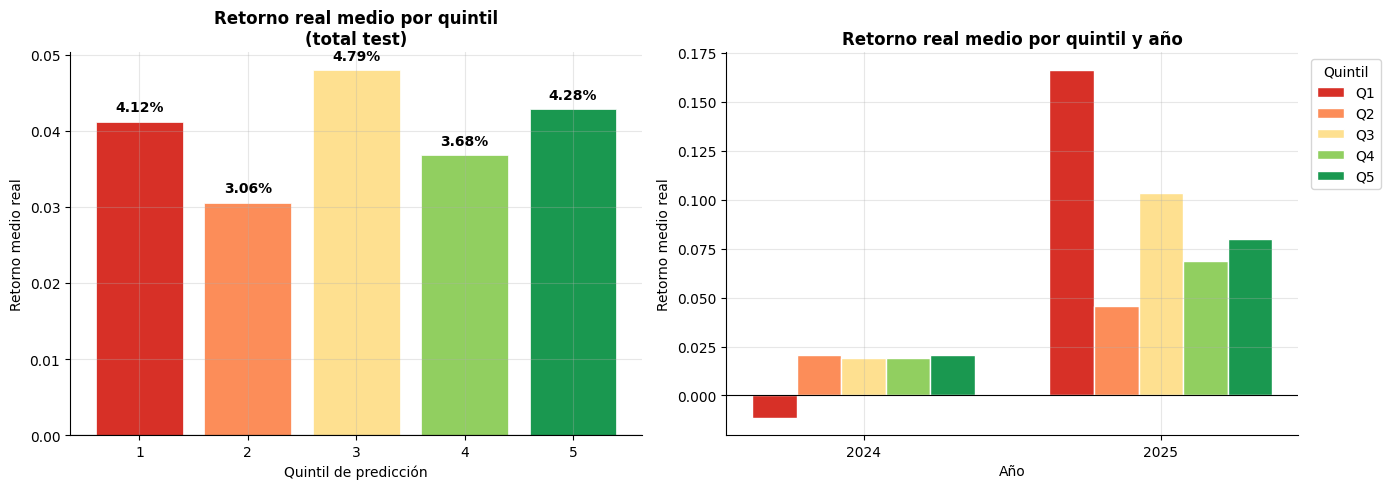

Grafico 5 guardado.


In [ ]:
# ==================================================
# GRAFICO 5: RETORNO MEDIO POR QUINTIL
# ==================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total
colores = ["#d73027", "#fc8d59", "#fee090", "#91cf60", "#1a9850"]
bars = axes[0].bar(
    [str(q) for q in retorno_quintil.index],
    retorno_quintil.values,
    color=colores, edgecolor="white", linewidth=0.5
)
axes[0].axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, retorno_quintil.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.2%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Quintil de predicción")
axes[0].set_ylabel("Retorno medio real")
axes[0].set_title("Retorno real medio por quintil\n(total test)", fontweight="bold")

# Por año
years  = retorno_anual.index.tolist()
x      = np.arange(len(years))
width  = 0.15
for i, q in enumerate([1, 2, 3, 4, 5]):
    axes[1].bar(x + i*width, retorno_anual[q].values, width,
                label=f"Q{q}", color=colores[i], edgecolor="white")
axes[1].set_xticks(x + 2*width)
axes[1].set_xticklabels([str(y) for y in years])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Retorno medio real")
axes[1].set_title("Retorno real medio por quintil y año", fontweight="bold")
axes[1].legend(title="Quintil", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.savefig(BASE_PATH / "grafico_quintiles.png", dpi=150)
plt.show()
print("Grafico 5 guardado.")

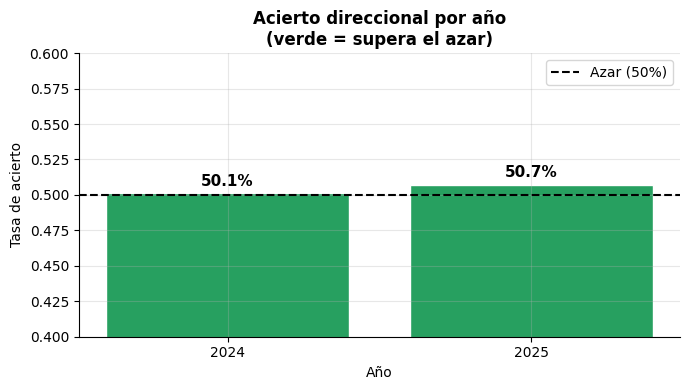

Grafico 6 guardado.


In [ ]:
# ==================================================
# GRAFICO 6: ACIERTO DIRECCIONAL POR AÑO
# ==================================================

fig, ax = plt.subplots(figsize=(7, 4))
colors_bar = ["#E05A2B" if v < 0.5 else "#27A060" for v in acierto_anual.values]
bars = ax.bar([str(y) for y in acierto_anual.index], acierto_anual.values,
              color=colors_bar, edgecolor="white")
ax.axhline(0.5, color="black", linewidth=1.5, linestyle="--", label="Azar (50%)")
for bar, val in zip(bars, acierto_anual.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.1%}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0.40, 0.60)
ax.set_xlabel("Año")
ax.set_ylabel("Tasa de acierto")
ax.set_title("Acierto direccional por año\n(verde = supera el azar)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(BASE_PATH / "grafico_acierto.png", dpi=150)
plt.show()
print("Grafico 6 guardado.")

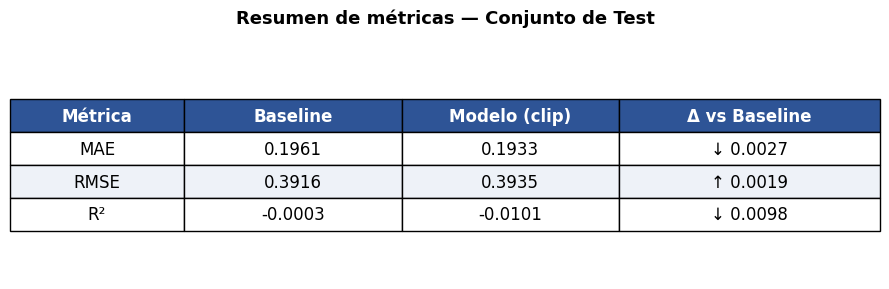

Grafico 7 guardado.


In [ ]:
# ==================================================
# GRAFICO 7: TABLA DE METRICAS FINALES (resumen visual)
# ==================================================

fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")

metricas_data = [
    ["Métrica",  "Baseline",         "Modelo (clip)",    "Δ vs Baseline"],
    ["MAE",      f"{baseline_mae:.4f}",  f"{mae_clip:.4f}",
     f"{'↓' if mae_clip < baseline_mae else '↑'} {abs(mae_clip - baseline_mae):.4f}"],
    ["RMSE",     f"{baseline_rmse:.4f}", f"{rmse_clip:.4f}",
     f"{'↓' if rmse_clip < baseline_rmse else '↑'} {abs(rmse_clip - baseline_rmse):.4f}"],
    ["R²",       f"{baseline_r2:.4f}",   f"{r2_clip:.4f}",
     f"{'↑' if r2_clip > baseline_r2 else '↓'} {abs(r2_clip - baseline_r2):.4f}"],
]

table = ax.table(
    cellText   = metricas_data[1:],
    colLabels  = metricas_data[0],
    cellLoc    = "center",
    loc        = "center",
    colWidths  = [0.20, 0.25, 0.25, 0.30],
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2E5496")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EEF2F8")

ax.set_title("Resumen de métricas — Conjunto de Test", fontweight="bold", pad=20, fontsize=13)
plt.tight_layout()
plt.savefig(BASE_PATH / "grafico_tabla_metricas.png", dpi=150)
plt.show()
print("Grafico 7 guardado.")

In [ ]:
# ==================================================
# DATAFRAME DE PREDICCIONES COMPLETO
# Incluye symbol, fecha, sector, retorno real,
# predicción, baseline y errores.
# Listo para comparar con SPY en otro notebook.
# ==================================================

df_predicciones = test_df[[symbol_col, date_col, target_col]].copy()

# Agregar sector desde el raw (antes del pipeline) para análisis posterior
sector_map = test_raw.set_index([symbol_col, date_col])["sector"] \
    if "sector" in test_raw.columns else None

df_predicciones["target_return_pred"]     = preds_clipped
df_predicciones["target_return_pred_raw"] = preds_test          # sin clip, para auditoría
df_predicciones["target_return_baseline"] = y_train_mean

df_predicciones["error_modelo"]    = (
    df_predicciones[target_col] - df_predicciones["target_return_pred"]
)
df_predicciones["error_baseline"]  = (
    df_predicciones[target_col] - df_predicciones["target_return_baseline"]
)
df_predicciones["abs_error_modelo"]   = df_predicciones["error_modelo"].abs()
df_predicciones["abs_error_baseline"] = df_predicciones["error_baseline"].abs()

df_predicciones["quintil_pred"] = pd.qcut(
    df_predicciones["target_return_pred"], q=5, labels=[1, 2, 3, 4, 5]
)
df_predicciones["year"]  = pd.to_datetime(df_predicciones[date_col]).dt.year
df_predicciones["month"] = pd.to_datetime(df_predicciones[date_col]).dt.month

# Agregar sector si está disponible
if sector_map is not None:
    df_predicciones = df_predicciones.join(
        sector_map.rename("sector"),
        on=[symbol_col, date_col],
        how="left"
    )

df_predicciones = df_predicciones.sort_values([date_col, symbol_col]).reset_index(drop=True)

print("\nShape df_predicciones:", df_predicciones.shape)
print("Años cubiertos:", sorted(df_predicciones["year"].unique()))
print("\nPrimeras filas:")
print(df_predicciones.head())

# Guardar en Drive
pred_path = BASE_PATH / "predicciones_test_2024_2025.parquet"
df_predicciones.to_parquet(pred_path, index=False)
print(f"\ndf_predicciones guardado en: {pred_path}")
print("Columnas disponibles para comparar con SPY:")
print(df_predicciones.columns.tolist())


Shape df_predicciones: (351882, 14)
Años cubiertos: [np.int32(2024), np.int32(2025)]

Primeras filas:
  symbol date_fundamentals  target_return  target_return_pred  \
0    BFI        2024-01-01      -0.197519            0.000625   
1  BFIIW        2024-01-01       0.143911            0.000625   
2   TTMI        2024-01-01       0.191734            0.006586   
3   BJRI        2024-01-02       0.004932            0.007852   
4   JACK        2024-01-21      -0.240619            0.007809   

   target_return_pred_raw  target_return_baseline  error_modelo  \
0                0.000625                0.033017     -0.198144   
1                0.000625                0.033017      0.143286   
2                0.006586                0.033017      0.185148   
3                0.007852                0.033017     -0.002920   
4                0.007809                0.033017     -0.248428   

   error_baseline  abs_error_modelo  abs_error_baseline quintil_pred  year  \
0       -0.230536        

In [ ]:
# ==================================================
# SERIALIZACION DEL ARTEFACTO
# ==================================================

output_path = BASE_PATH / "modelo_simplificado.pkl"

artifact = {
    "pipeline":     pipeline,
    "feature_cols": feature_cols,
    "final_params": final_params,
    "model_state":  final_model.state_dict(),
    "model_config": {
        "n_features":      X_train.shape[1],
        "hidden_units":    final_params["hidden_units"],
        "dropout":         final_params["dropout"],
        "activation_name": final_params["activation"],
    },
    "clip_lower": float(clip_lower),
    "clip_upper": float(clip_upper),
    "history":    history,
    "metrics_test": {
        "mse_clip":  float(mse_clip),
        "rmse_clip": float(rmse_clip),
        "mae_clip":  float(mae_clip),
        "r2_clip":   float(r2_clip),
    },
    "metrics_baseline": {
        "mse": float(baseline_mse), "rmse": float(baseline_rmse),
        "mae": float(baseline_mae), "r2":   float(baseline_r2),
    },
}

with open(output_path, "wb") as f:
    pickle.dump(artifact, f)

print(f"\nModelo serializado en: {output_path}")
print("\nArchivos guardados en Drive:")
for p in sorted(BASE_PATH.glob("*")):
    print(f"  {p.name}")


Modelo serializado en: /content/drive/MyDrive/Tesis/red_neuronal_final/modelo_simplificado.pkl

Archivos guardados en Drive:
  df_input_inicial.parquet
  df_mini.parquet
  dnn_modelo_completo_unificado_v1.ipynb
  grafico_acierto.png
  grafico_distribucion.png
  grafico_metricas_validacion.png
  grafico_quintiles.png
  grafico_scatter.png
  grafico_tabla_metricas.png
  modelo_1
  modelo_2
  modelo_3
  modelo_4
  modelo_5
  modelo_completo_v1.ipynb
  modelo_final.pkl
  modelo_mejorado_v3.pkl
  modelo_simplificado.pkl
  modelo_sin_c_sin_lstm_sin_industry_v4.ipynb
  modelo_sin_c_sin_lstm_v3.ipynb
  modelo_sin_c_v2.ipynb
  predicciones_test_2024_2025.parquet
  pruebas_modelos_nuevos
